In [ ]:
!pip install openpyxl


In [ ]:
# ── Import libraries ──────────────────────────────────────
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# ── Load the 3 datasets ───────────────────────────────────
engines = pd.read_csv('engines_clean.csv')
history = pd.read_csv('maintenance_history.csv')
parts   = pd.read_csv('spare_parts.csv')

# Quick check
print("✅ engines shape:", engines.shape)
print("✅ history shape:", history.shape)
print("✅ parts shape:  ", parts.shape)

✅ engines shape: (44, 13)
✅ history shape: (1150, 7)
✅ parts shape:   (8, 6)


In [ ]:
# ── First look at the engines table ──────────────────────
print("=" * 50)
print("ENGINES TABLE — First 5 rows")
print("=" * 50)
print(engines.head())

print("\n" + "=" * 50)
print("COLUMN NAMES AND DATA TYPES")
print("=" * 50)
print(engines.dtypes)

print("\n" + "=" * 50)
print("MISSING VALUES PER COLUMN")
print("=" * 50)
print(engines.isnull().sum())

print("\n" + "=" * 50)
print("STATUS DISTRIBUTION")
print("=" * 50)
print(engines['Status'].value_counts())
# Standardize all column names to lowercase
engines.columns = engines.columns.str.lower()
history.columns = history.columns.str.lower()
parts.columns   = parts.columns.str.lower()

print("✅ All column names standardized to lowercase!")
print("Engines columns:", list(engines.columns))

ENGINES TABLE — First 5 rows
  engine_id          category engine_unit seriel_num  early_main_date  \
0    ENG001  Groupe Demarrage         asu     t60023              NaN   
1    ENG002  Groupe Demarrage         asu     t22907              NaN   
2    ENG003       Groupe Clim         acu     t23855              NaN   
3    ENG004       Groupe Clim         acu        t86              NaN   
4    ENG005  Groupe Demarrage         gpu    318PS22              NaN   

   prev_main_date  Next_Maintenance_Date  Days_Since_Maintenance  Last_Hours  \
0             NaN                    NaN                   127.0        1926   
1             NaN                    NaN                   114.0        2259   
2             NaN                    NaN                   118.0        1660   
3             NaN                    NaN                    65.0        2094   
4             NaN                    NaN                    66.0        1930   

   Current_Hours  Hours_Used Maintenance_Type      

In [ ]:
# ── Create SQLite database in Colab ──────────────────────
conn = sqlite3.connect('maintenance.db')

# Save all tables into the database
engines.to_sql('engines',             conn, if_exists='replace', index=False)
history.to_sql('maintenance_history', conn, if_exists='replace', index=False)
parts.to_sql('spare_parts',           conn, if_exists='replace', index=False)

print("✅ Database created successfully!")
print("✅ Tables created: engines, maintenance_history, spare_parts")

✅ Database created successfully!
✅ Tables created: engines, maintenance_history, spare_parts


In [ ]:
# ── Query 1: Fleet status summary ────────────────────────
query = """
SELECT
    status,
    COUNT(*) AS total_engines,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM engines), 1) AS percentage
FROM engines
GROUP BY status
ORDER BY total_engines DESC
"""

result = pd.read_sql_query(query, conn)

print("=" * 40)
print("  FLEET STATUS SUMMARY")
print("=" * 40)
print(result)

  FLEET STATUS SUMMARY
            status  total_engines  percentage
0               OK             32        72.7
1             Soon              7        15.9
2  Maintenance Due              5        11.4


In [ ]:
# ── Query 2: Engines overdue for maintenance ──────────────
query = """
SELECT
    engine_id,
    category,
    engine_unit,
    days_since_maintenance,
    next_maintenance_date
FROM engines
WHERE status = 'Maintenance Due'
ORDER BY days_since_maintenance DESC
"""

overdue = pd.read_sql_query(query, conn)

print("=" * 50)
print("  ⚠️  ENGINES OVERDUE FOR MAINTENANCE")
print("=" * 50)
print(overdue)
print(f"\n→ Total overdue engines: {len(overdue)}")

  ⚠️  ENGINES OVERDUE FOR MAINTENANCE
  engine_id          category engine_unit  days_since_maintenance  \
0    ENG044    Porte Escalier         abs                   135.0   
1    ENG001  Groupe Demarrage         asu                   127.0   
2    ENG043    Porte Escalier         abs                   126.0   
3    ENG009  Groupe Demarrage         gpu                   123.0   
4    ENG032        Floodlight    fldlight                    95.0   

  next_maintenance_date  
0                  None  
1                  None  
2                  None  
3                  None  
4                  None  

→ Total overdue engines: 5


In [ ]:
# ── Query 3: Maintenance summary by category ──────────────
query = """
SELECT
    category,
    COUNT(*) AS total_engines,
    SUM(CASE WHEN status = 'Maintenance Due' THEN 1 ELSE 0 END) AS overdue,
    SUM(CASE WHEN status = 'Soon'            THEN 1 ELSE 0 END) AS coming_soon,
    SUM(CASE WHEN status = 'OK'              THEN 1 ELSE 0 END) AS ok,
    ROUND(AVG(days_since_maintenance), 1) AS avg_days
FROM engines
GROUP BY category
ORDER BY overdue DESC
"""

by_category = pd.read_sql_query(query, conn)

print("=" * 60)
print("  MAINTENANCE SUMMARY BY CATEGORY")
print("=" * 60)
print(by_category.to_string(index=False))

  MAINTENANCE SUMMARY BY CATEGORY
        category  total_engines  overdue  coming_soon  ok  avg_days
  Porte Escalier              5        2            0   3      89.6
Groupe Demarrage              7        2            3   2      98.6
      Floodlight              4        1            0   3      75.3
Water & Lavatory              4        0            0   4      59.8
        Tracteur             11        0            3   8      65.4
     Porte Tapis              2        0            0   2      66.0
         Nacelle              3        0            0   3      65.0
          Loader              2        0            0   2      63.0
     Groupe Clim              2        0            1   1      91.5
       Elevateur              2        0            0   2      63.5
          Camion              2        0            0   2      65.5


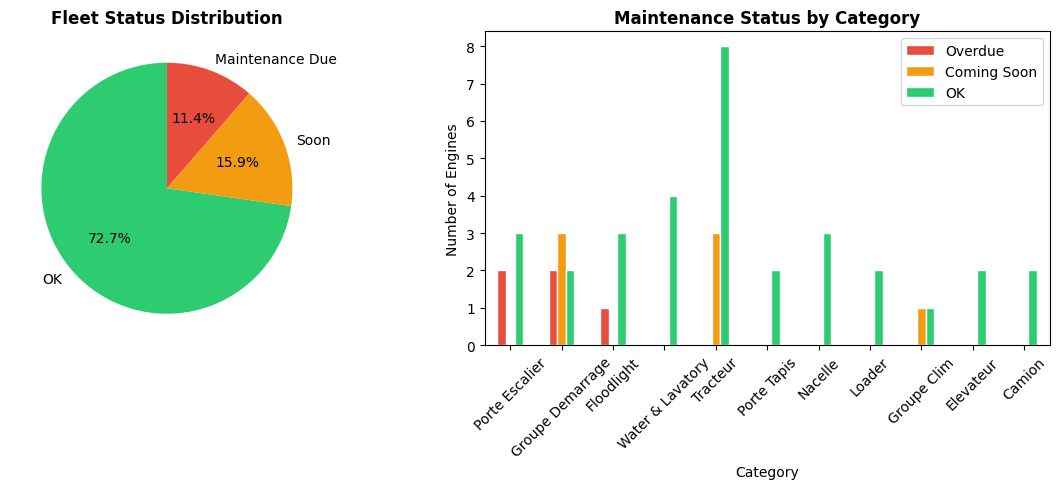

✅ Chart saved as fleet_status.png


In [ ]:
# ── Chart 1: Fleet Status Overview ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: Pie chart ───────────────────────────────────────
status_counts = engines['status'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']

axes[0].pie(
    status_counts,
    labels=status_counts.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
axes[0].set_title('Fleet Status Distribution', fontweight='bold')

# ── Right: Bar chart by category ─────────────────────────
by_category.plot(
    x='category',
    y=['overdue', 'coming_soon', 'ok'],
    kind='bar',
    ax=axes[1],
    color=['#e74c3c', '#f39c12', '#2ecc71'],
    edgecolor='white'
)
axes[1].set_title('Maintenance Status by Category', fontweight='bold')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Number of Engines')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(['Overdue', 'Coming Soon', 'OK'])

plt.tight_layout()
plt.savefig('fleet_status.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as fleet_status.png")

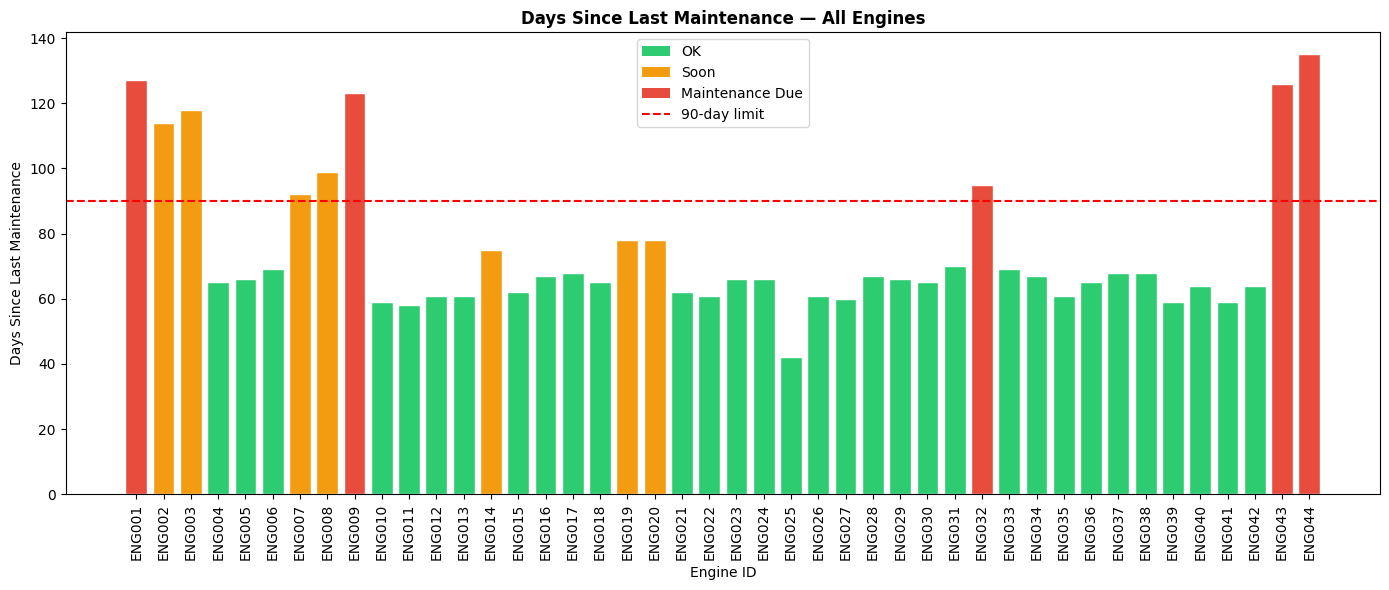

✅ Chart saved as days_since_maintenance.png


In [ ]:
# ── Chart 2: Days Since Maintenance per Engine ────────────
fig, ax = plt.subplots(figsize=(14, 6))

# Color each bar based on status
colors_map = {
    'OK':              '#2ecc71',
    'Soon':            '#f39c12',
    'Maintenance Due': '#e74c3c'
}
bar_colors = engines['status'].map(colors_map)

ax.bar(
    engines['engine_id'],
    engines['days_since_maintenance'],
    color=bar_colors,
    edgecolor='white'
)

# Add threshold line at 90 days
ax.axhline(y=90, color='red', linestyle='--', linewidth=1.5, label='90-day limit')

ax.set_title('Days Since Last Maintenance — All Engines', fontweight='bold')
ax.set_xlabel('Engine ID')
ax.set_ylabel('Days Since Last Maintenance')
ax.tick_params(axis='x', rotation=90)

# Add legend manually
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='OK'),
    Patch(facecolor='#f39c12', label='Soon'),
    Patch(facecolor='#e74c3c', label='Maintenance Due'),
    plt.Line2D([0], [0], color='red', linestyle='--', label='90-day limit')
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.savefig('days_since_maintenance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as days_since_maintenance.png")

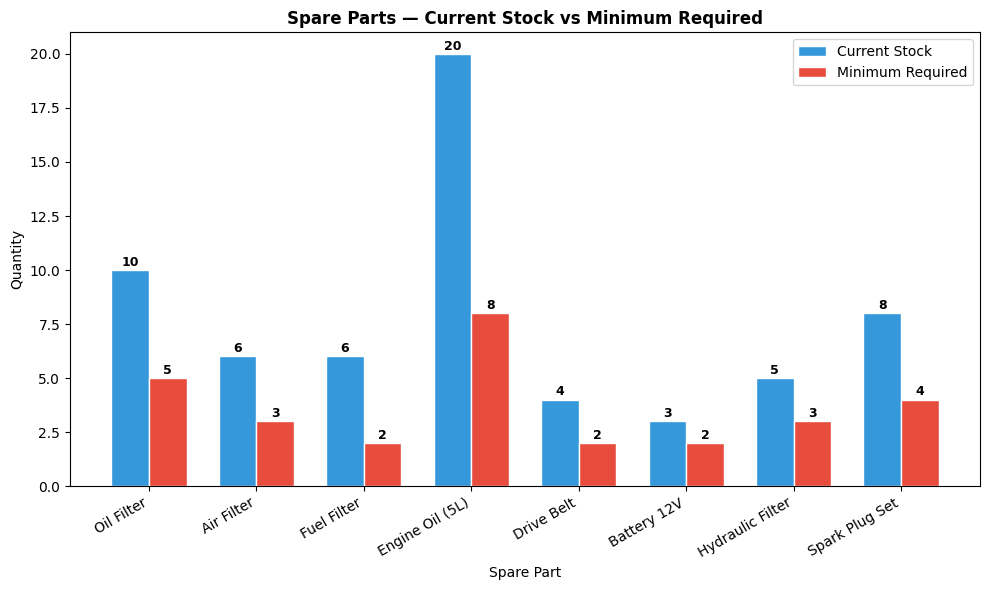

✅ Chart saved as spare_parts_inventory.png


In [ ]:
# ── Chart 3: Spare Parts Inventory vs Minimum Stock ──────
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(parts))
width = 0.35

# Two bars side by side
bars1 = ax.bar(
    [i - width/2 for i in x],
    parts['stock_qty'],
    width,
    label='Current Stock',
    color='#3498db',
    edgecolor='white'
)
bars2 = ax.bar(
    [i + width/2 for i in x],
    parts['min_stock'],
    width,
    label='Minimum Required',
    color='#e74c3c',
    edgecolor='white'
)

# Add value labels on top of each bar
for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        str(int(bar.get_height())),
        ha='center', fontsize=9, fontweight='bold'
    )
for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.2,
        str(int(bar.get_height())),
        ha='center', fontsize=9, fontweight='bold'
    )

ax.set_title('Spare Parts — Current Stock vs Minimum Required', fontweight='bold')
ax.set_xlabel('Spare Part')
ax.set_ylabel('Quantity')
ax.set_xticks(list(x))
ax.set_xticklabels(parts['part_name'], rotation=30, ha='right')
ax.legend()

plt.tight_layout()
plt.savefig('spare_parts_inventory.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved as spare_parts_inventory.png")

In [ ]:
# ── Prepare features for classification ──────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import LabelEncoder

# Select features the model will learn from
features = [
    'days_since_maintenance',
    'hours_used',
    'current_hours'
]

# Target — what we want to predict
target = 'status'

# Drop rows with missing values in these columns
ml_data = engines[features + [target]].dropna()

# Encode target: OK=0, Soon=1, Maintenance Due=2
le = LabelEncoder()
ml_data = ml_data.copy()
ml_data['status_encoded'] = le.fit_transform(ml_data[target])

print("✅ Classes found:", list(le.classes_))
print("✅ Encoding:      ", dict(zip(le.classes_, le.transform(le.classes_))))
print("✅ Dataset ready:", ml_data.shape)
print(ml_data.head())

✅ Classes found: ['Maintenance Due', 'OK', 'Soon']
✅ Encoding:       {'Maintenance Due': np.int64(0), 'OK': np.int64(1), 'Soon': np.int64(2)}
✅ Dataset ready: (44, 5)
   days_since_maintenance  hours_used  current_hours           status  \
0                   127.0          64           1990  Maintenance Due   
1                   114.0         239           2498             Soon   
2                   118.0         239           1899             Soon   
3                    65.0         224           2318               OK   
4                    66.0         239           2169               OK   

   status_encoded  
0               0  
1               2  
2               2  
3               1  
4               1  


In [ ]:
# ── Split data into Train and Test sets ───────────────────
X = ml_data[features]           # input features
y = ml_data['status_encoded']   # target to predict

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=42     # ensures same split every time
)

print("✅ Data split complete!")
print(f"   Training set:  {X_train.shape[0]} engines")
print(f"   Testing set:   {X_test.shape[0]} engines")
print(f"\n   Features used: {features}")
print(f"   Target:        status (0=OK, 1=Soon, 2=Maintenance Due)")

✅ Data split complete!
   Training set:  35 engines
   Testing set:   9 engines

   Features used: ['days_since_maintenance', 'hours_used', 'current_hours']
   Target:        status (0=OK, 1=Soon, 2=Maintenance Due)


In [ ]:
# ── Train the model ───────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,   # 100 decision trees
    random_state=42     # reproducible results
)

model.fit(X_train, y_train)

print("✅ Model trained successfully!")
print(f"   Algorithm:    Random Forest Classifier")
print(f"   Trees used:   100")
print(f"   Trained on:   {X_train.shape[0]} engines")

✅ Model trained successfully!
   Algorithm:    Random Forest Classifier
   Trees used:   100
   Trained on:   35 engines


In [ ]:
# ── Make predictions ──────────────────────────────────────
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("✅ Predictions made!")
print(f"\n   Total engines tested:    {len(y_test)}")
print(f"   Correctly predicted:     {sum(y_test == y_pred)}")
print(f"   Wrongly predicted:       {sum(y_test != y_pred)}")
print(f"\n   Accuracy:                {accuracy:.2f} = {accuracy*100:.1f}%")

✅ Predictions made!

   Total engines tested:    9
   Correctly predicted:     9
   Wrongly predicted:       0

   Accuracy:                1.00 = 100.0%


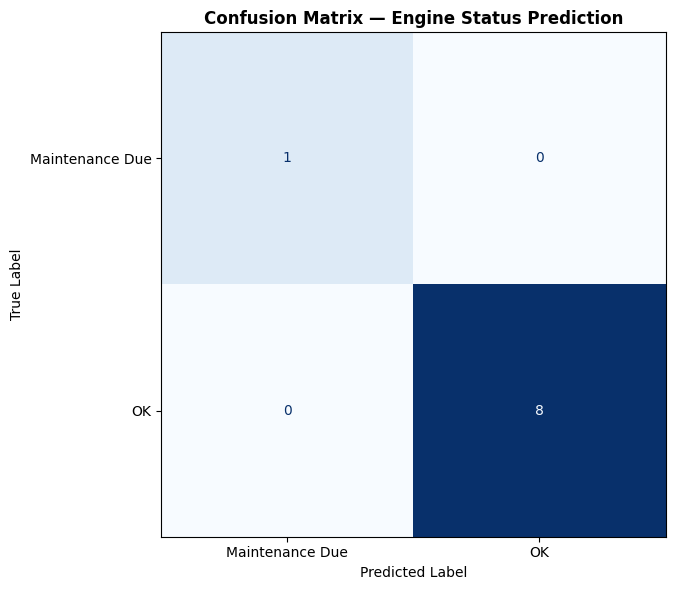

✅ Confusion Matrix saved!

Classes in test set: ['Maintenance Due', 'OK']
Confusion Matrix:
[[1 0]
 [0 8]]


In [ ]:
# ── Confusion Matrix (fixed) ──────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Get only the classes that appear in y_test
classes_in_test = le.inverse_transform(sorted(y_test.unique()))

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes_in_test
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Confusion Matrix — Engine Status Prediction', fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Confusion Matrix saved!")
print(f"\nClasses in test set: {list(classes_in_test)}")
print(f"Confusion Matrix:\n{cm}")

In [ ]:
# ── Classification Report ─────────────────────────────────
from sklearn.metrics import classification_report

# Use only classes present in test set
report = classification_report(
    y_test,
    y_pred,
    target_names=classes_in_test
)

print("=" * 55)
print("  CLASSIFICATION REPORT")
print("=" * 55)
print(report)
print("""
Key metric → RECALL for 'Maintenance Due'
Reason: Missing an engine that needs maintenance
is the most dangerous outcome — safety risk!
A False Negative means an engine runs without
service → equipment failure → operations stop!
""")



  CLASSIFICATION REPORT
                 precision    recall  f1-score   support

Maintenance Due       1.00      1.00      1.00         1
             OK       1.00      1.00      1.00         8

       accuracy                           1.00         9
      macro avg       1.00      1.00      1.00         9
   weighted avg       1.00      1.00      1.00         9


Key metric → RECALL for 'Maintenance Due'
Reason: Missing an engine that needs maintenance
is the most dangerous outcome — safety risk!
A False Negative means an engine runs without
service → equipment failure → operations stop!



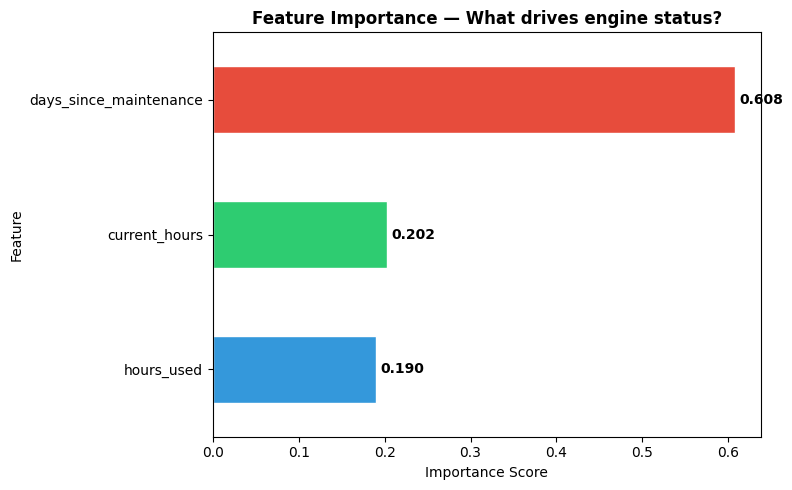

✅ Feature Importance chart saved!


In [ ]:
# ── Feature Importance ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=True)

colors = ['#3498db', '#2ecc71', '#e74c3c']
importance.plot(
    kind='barh',
    ax=ax,
    color=colors,
    edgecolor='white'
)

ax.set_title('Feature Importance — What drives engine status?',
             fontweight='bold')
ax.set_xlabel('Importance Score')
ax.set_ylabel('Feature')

for i, v in enumerate(importance):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature Importance chart saved!")